<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkST0151ENSkillsNetwork20531532-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>



#### Import the required libraries we need for the lab.


In [15]:
import piplite
await piplite.install(['numpy'],['pandas'])
await piplite.install(['seaborn'])

In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

#### Read the dataset in the csv file from the URL


In [17]:
from js import fetch
import io

URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv'
resp = await fetch(URL)
boston_url = io.BytesIO((await resp.arrayBuffer()).to_py())

In [18]:
boston_df=pd.read_csv(boston_url)

#### Add your code below following the instructions given in the course to complete the peer graded assignment


In [22]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  506 non-null    int64  
 1   CRIM        506 non-null    float64
 2   ZN          506 non-null    float64
 3   INDUS       506 non-null    float64
 4   CHAS        506 non-null    float64
 5   NOX         506 non-null    float64
 6   RM          506 non-null    float64
 7   AGE         506 non-null    float64
 8   DIS         506 non-null    float64
 9   RAD         506 non-null    float64
 10  TAX         506 non-null    float64
 11  PTRATIO     506 non-null    float64
 12  LSTAT       506 non-null    float64
 13  MEDV        506 non-null    float64
dtypes: float64(13), int64(1)
memory usage: 55.4 KB


In [23]:
boston_df.describe()

,Unnamed: 0,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,252.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,7.141062,9.197104
min,0.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,1.730000,5.000000
25%,126.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,6.950000,17.025000
50%,252.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,11.360000,21.200000
75%,378.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,16.955000,25.000000
max,505.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,37.970000,50.000000


In [24]:
print(boston_df.isnull().sum())

Unnamed: 0    0
CRIM          0
ZN            0
INDUS         0
CHAS          0
NOX           0
RM            0
AGE           0
DIS           0
RAD           0
TAX           0
PTRATIO       0
LSTAT         0
MEDV          0
dtype: int64


In [34]:
#Code used to check Outliers in the data.

# plt.figure(figsize =(15, 10))
# boston_df.boxplot()
# plt.xticks(rotation = 45)
# plt.title('Boxplot of all features')
# plt.show()

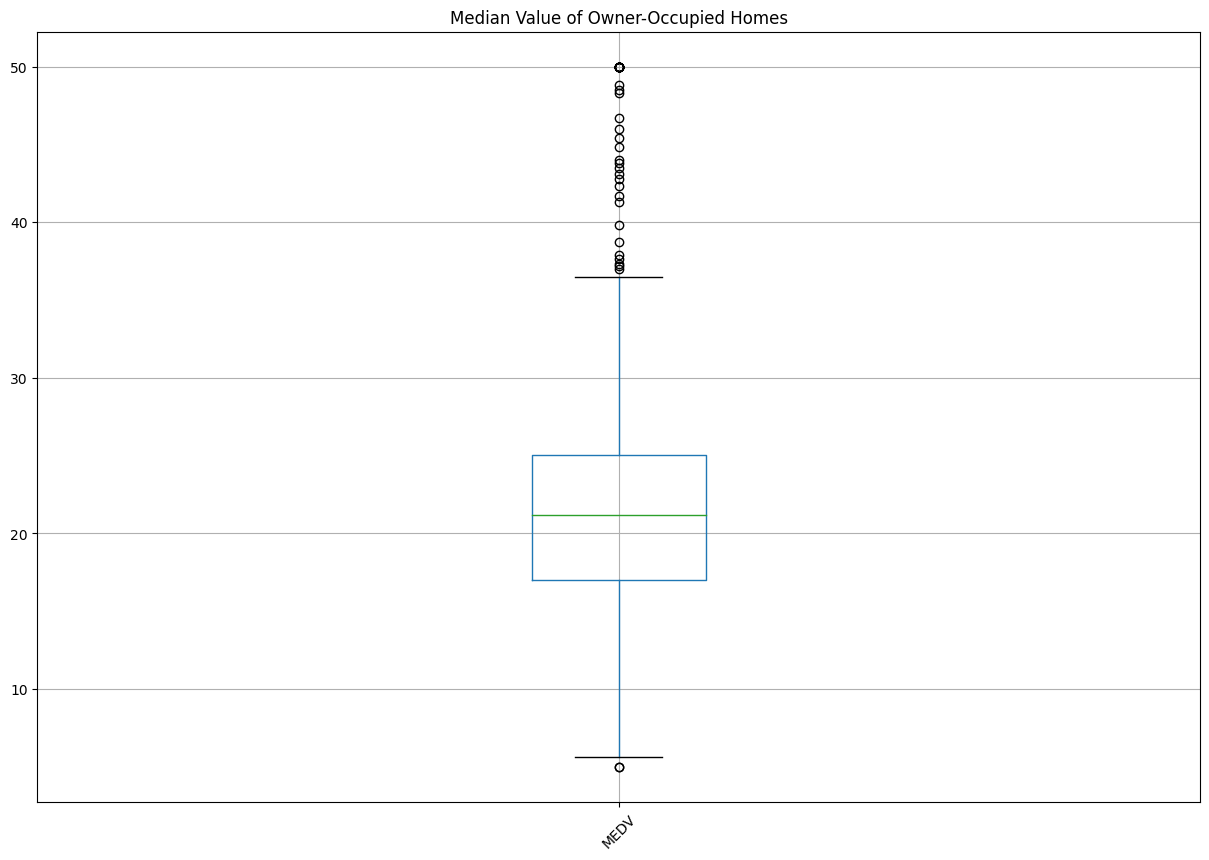

In [37]:
plt.figure(figsize = (15, 10))
boston_df.boxplot('MEDV')
plt.xticks(rotation = 45)
plt.title('Median Value of Owner-Occupied homes')
plt.show()

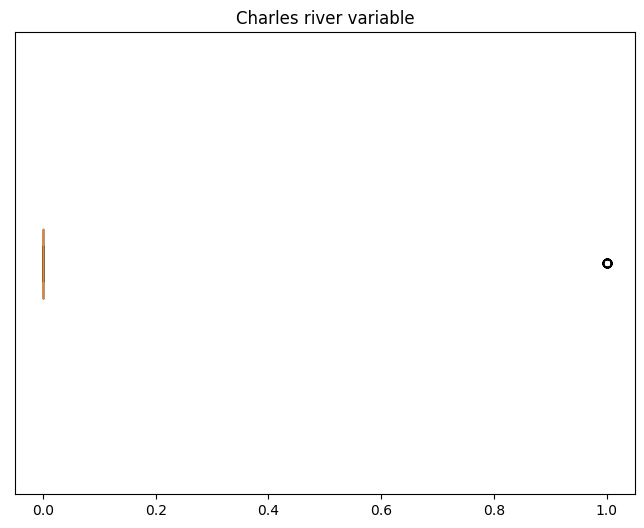

In [40]:
plt.figure(figsize = (8, 6))
plt.boxplot(boston_df['CHAS'], vert = False)
plt.title('Charles river variable')
plt.yticks([])
plt.show()

<ipython-input-44-c8ee26b2a039>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df, palette='viridis')
<ipython-input-44-c8ee26b2a039>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medians = boston_df.groupby('AGE_GROUP')['MEDV'].median()


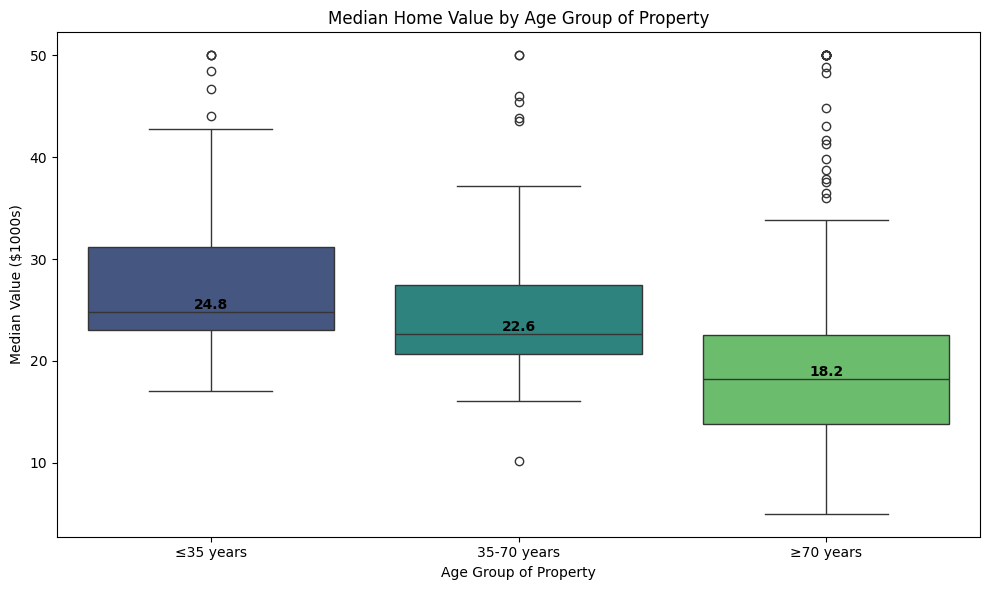

In [44]:
boston_df['AGE_GROUP'] = pd.cut(boston_df['AGE'],
                        bins=[0, 35, 70, np.inf],
                        labels=['≤35 years', '35-70 years', '≥70 years'])

plt.figure(figsize=(10, 6))
sns.boxplot(x='AGE_GROUP', y='MEDV', data=boston_df, palette='viridis')

plt.title('Median Home Value by Age Group of Property')
plt.xlabel('Age Group of Property')
plt.ylabel('Median Value ($1000s)')

medians = boston_df.groupby('AGE_GROUP')['MEDV'].median()
for i, median in enumerate(medians):
    plt.text(i, median, f'{median:.1f}', 
             ha='center', va='bottom', 
             fontweight='bold',
             color='black')

plt.tight_layout()
plt.show()

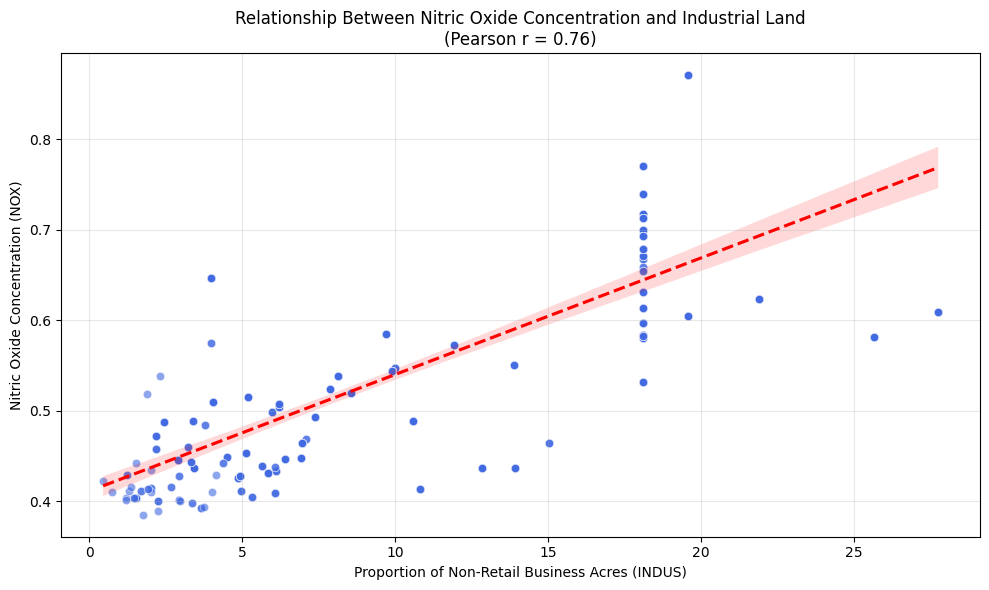

In [50]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='INDUS', y='NOX', data=boston_df, alpha=0.6, color='royalblue')

sns.regplot(x='INDUS', y='NOX', data=boston_df, scatter=False, color='red', line_kws={'linestyle':'--'})

corr = boston_df['INDUS'].corr(boston_df['NOX'])

plt.title(f'Relationship Between Nitric Oxide Concentration and Industrial Land\n(Pearson r = {corr:.2f})')
plt.xlabel('Proportion of Non-Retail Business Acres (INDUS)')
plt.ylabel('Nitric Oxide Concentration (NOX)')

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

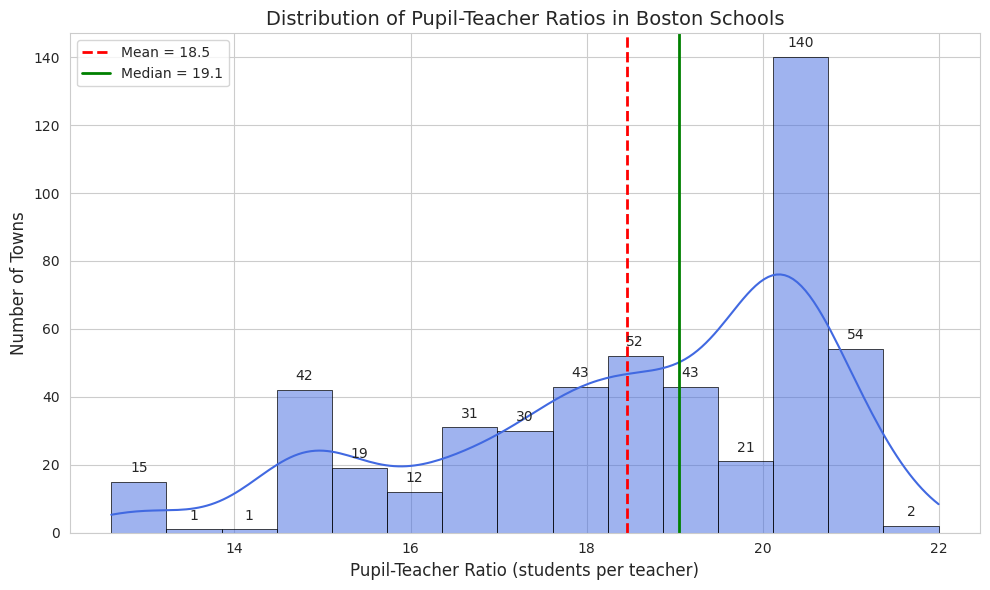

In [51]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.histplot(boston_df['PTRATIO'], 
                 bins=15, 
                 kde=True, 
                 color='royalblue',
                 edgecolor='black',
                 linewidth=0.5)

mean_val = boston_df['PTRATIO'].mean()
median_val = boston_df['PTRATIO'].median()
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean_val:.1f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median = {median_val:.1f}')

plt.title('Distribution of Pupil-Teacher Ratios in Boston Schools', fontsize=14)
plt.xlabel('Pupil-Teacher Ratio (students per teacher)', fontsize=12)
plt.ylabel('Number of Towns', fontsize=12)
plt.legend()

for rect in ax.patches:
    height = rect.get_height()
    if height > 0:  # Only label bars with height > 0
        ax.text(rect.get_x() + rect.get_width()/2, 
                height + 2, 
                f'{int(height)}', 
                ha='center', 
                va='bottom')

plt.tight_layout()
plt.show()